# 4 · Trainability diagnostics: barren plateaus

A model has a **barren plateau** if the variance of its loss gradient vanishes
(typically exponentially) as the system grows — making training intractable.
`qbmkit` ships diagnostics that reuse the *same* gradient/metric estimators as
training, so the study is faithful.

We measure $\mathrm{Var}[\partial_j L]$ over random parameter points as a function
of qubit number $n$, for the energy loss of a transverse-field Ising model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm

def make_model_for_n(n):
    return lambda: qbm.FullyVisibleQBM(n=n)

def make_loss_for_n(n):
    return qbm.losses.Energy(qbm.hamiltonians.tfim(n, g=1.0))

sizes = [2, 3, 4, 5, 6]
var = qbm.diagnostics.barren_plateau_scan(
    make_model_for_n, make_loss_for_n, sizes=sizes, n_samples=120, scale=1.0
)
for n in sizes:
    print(f"n={n}:  mean gradient variance = {var[n]:.3e}")

n=2:  mean gradient variance = 6.799e-02
n=3:  mean gradient variance = 9.060e-02
n=4:  mean gradient variance = 1.057e-01
n=5:  mean gradient variance = 1.152e-01
n=6:  mean gradient variance = 1.113e-01


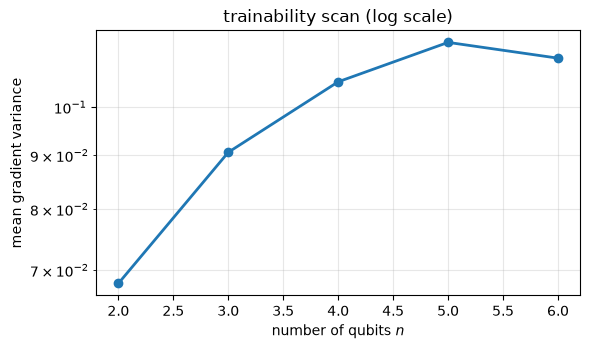

In [2]:
plt.figure(figsize=(6, 3.6))
plt.semilogy(sizes, [var[n] for n in sizes], "o-", lw=2)
plt.xlabel("number of qubits $n$")
plt.ylabel("mean gradient variance")
plt.title("trainability scan (log scale)")
plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

### Reading the plot

A barren plateau shows up as a **straight downward line** on this log scale — the
gradient variance decaying (typically exponentially) with $n$. Here the variance
stays essentially **flat**: this fully-visible QBM energy landscape does **not**
exhibit a barren plateau over this range. That matches the theoretical result that
thermal-state (Gibbs) QBM ground-state-energy training avoids the barren plateaus
that plague deep parameterized circuits (arXiv:2410.12935) — a key motivation for
QBMs.

The point of the tool is the methodology: because the diagnostic calls the *exact
same* `loss.grad` an optimizer uses, what you measure is exactly what training
would experience. Swap in any model factory (e.g. `VisibleHiddenQBM`), any loss,
or larger sizes, and study the metric spectrum (`state.metric(...)`) the same way —
a plateau-prone setup would bend this curve downward.